# 학생 우울증 분류 — ML Term Project

데이터사이언스학과 12214214 김민성 | [GitHub](https://github.com/mynseong02/26ML_TERM_PROJECT) | [Dataset](https://www.kaggle.com/datasets/hopesb/student-depression-dataset)

## I. 서론

학생 우울증은 조기 발견 시 부정적 결과를 줄일 수 있다. 본 분석은 **FN 최소화**를 우선시한다.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, recall_score, precision_score,
    f1_score, fbeta_score, precision_recall_curve, auc, accuracy_score,
    roc_auc_score
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## II. EDA — 변수 설명

| 변수 | 설명 |
|---|---|
| Age / Gender | 나이 / 성별 |
| Academic Pressure / Work Pressure | 학업·업무 스트레스 |
| CGPA | 학점 |
| Study / Job Satisfaction | 학업·직업 만족도 |
| Sleep Duration / Dietary Habits | 수면 / 식습관 |
| Degree | 학위 |
| Suicidal Thoughts | 자살 생각 |
| Work/Study Hours | 공부·근무 시간 |
| Financial Stress | 재정 스트레스 |
| Family History of Mental Illness | 가족 정신질환력 |
| **Depression** | **타겟** |

인도 학생 27,901명 설문.

In [2]:
df = pd.read_csv('student_depression_dataset.csv')
print('Shape:', df.shape)
print('\nMissing values (raw):')
print(df.isnull().sum().sum())
df.head()

Shape: (27901, 18)

Missing values (raw):
0


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


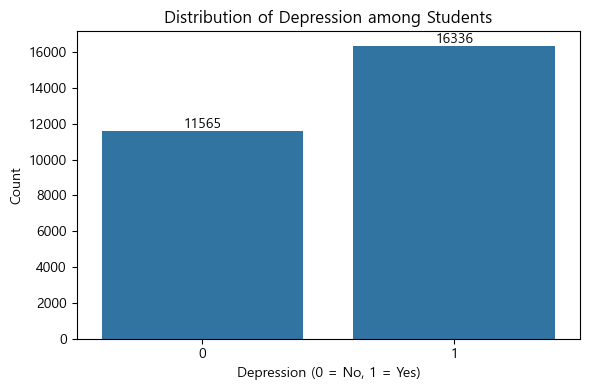

Depression
1    16336
0    11565
Name: count, dtype: int64

Class ratio: {1: 0.585, 0: 0.415}


In [3]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Depression', data=df, order=[0, 1])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')
plt.title('Distribution of Depression among Students')
plt.xlabel('Depression (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(df['Depression'].value_counts())
ratio = df['Depression'].value_counts(normalize=True).round(3).to_dict()
print(f'\nClass ratio: {ratio}')

클래스 비율 약 6:4 — 별도 리샘플링 없이 `class_weight='balanced'`로 대응.

In [4]:
data = df.copy()

data = data.drop(columns=['id', 'City'])
data = data[data['Profession'] == 'Student'].drop(columns=['Profession'])

for col in ['Sleep Duration', 'Degree']:
    data[col] = data[col].astype(str).str.strip("'").str.strip()

data = data[data['Sleep Duration'] != 'Others']
data = data[data['Dietary Habits'] != 'Others']
data = data[data['Financial Stress'] != '?']
data['Financial Stress'] = data['Financial Stress'].astype(float)

binary_map = {'Yes': 1, 'No': 0}
data['Suicidal_Thoughts'] = data['Have you ever had suicidal thoughts ?'].map(binary_map)
data['Family_History'] = data['Family History of Mental Illness'].map(binary_map)
data['Gender_Female'] = (data['Gender'] == 'Female').astype(int)

# Sleep Duration 원-핫 (baseline: 7-8 hours)
data['Sleep_lt5'] = (data['Sleep Duration'] == 'Less than 5 hours').astype(int)
data['Sleep_5to6'] = (data['Sleep Duration'] == '5-6 hours').astype(int)
data['Sleep_gt8'] = (data['Sleep Duration'] == 'More than 8 hours').astype(int)

# Dietary Habits 원-핫 (baseline: Healthy)
data['Diet_Moderate'] = (data['Dietary Habits'] == 'Moderate').astype(int)
data['Diet_Unhealthy'] = (data['Dietary Habits'] == 'Unhealthy').astype(int)

# Degree 그룹화 (baseline: Bachelor)
bachelor = {'Class 12', 'BA', 'BSc', 'B.Com', 'BCA', 'B.Ed', 'B.Pharm',
            'B.Arch', 'B.Tech', 'BBA', 'BHM', 'BE', 'LLB'}
master = {'MA', 'MSc', 'M.Com', 'MCA', 'M.Ed', 'M.Pharm', 'M.Tech',
          'MBA', 'ME', 'MHM', 'LLM'}
doctor = {'MBBS', 'MD', 'PhD'}

def deg_group(x):
    if x in bachelor: return 'Bachelor'
    if x in master:   return 'Master'
    if x in doctor:   return 'Doctor'
    return 'Other'

data['Degree_Group'] = data['Degree'].apply(deg_group)
data = data[data['Degree_Group'] != 'Other']
data['Degree_Master'] = (data['Degree_Group'] == 'Master').astype(int)
data['Degree_Doctor'] = (data['Degree_Group'] == 'Doctor').astype(int)

data = data.rename(columns={
    'Academic Pressure': 'Academic_Pressure',
    'Work Pressure':     'Work_Pressure',
    'Study Satisfaction':'Study_Satisfaction',
    'Job Satisfaction':  'Job_Satisfaction',
    'Work/Study Hours':  'WorkStudy_Hours',
    'Financial Stress':  'Financial_Stress',
})

continuous_cols = ['Age', 'Academic_Pressure', 'CGPA', 'Study_Satisfaction',
                   'WorkStudy_Hours', 'Financial_Stress']
features = continuous_cols + [
    'Suicidal_Thoughts', 'Family_History', 'Gender_Female',
    'Sleep_lt5', 'Sleep_5to6', 'Sleep_gt8',
    'Diet_Moderate', 'Diet_Unhealthy',
    'Degree_Master', 'Degree_Doctor'
]
target = 'Depression'

data_model = data[features + [target]].copy()
print('Processed shape:', data_model.shape)
print('Class balance:', data_model[target].value_counts().to_dict())
data_model.head()

Processed shape: (27802, 17)
Class balance: {1: 16269, 0: 11533}


,Age,Academic_Pressure,CGPA,Study_Satisfaction,WorkStudy_Hours,Financial_Stress,Suicidal_Thoughts,Family_History,Gender_Female,Sleep_lt5,Sleep_5to6,Sleep_gt8,Diet_Moderate,Diet_Unhealthy,Degree_Master,Degree_Doctor,Depression
0,33.0,5.0,8.97,2.0,3.0,1.0,1,0,0,0,1,0,0,0,0,0,1
1,24.0,2.0,5.90,5.0,3.0,2.0,0,1,1,0,1,0,1,0,0,0,0
2,31.0,3.0,7.03,5.0,9.0,1.0,0,1,0,1,0,0,0,0,0,0,0
3,28.0,3.0,5.59,2.0,4.0,5.0,1,1,1,0,0,0,1,0,0,0,1
4,25.0,4.0,8.13,3.0,1.0,1.0,1,0,1,0,1,0,1,0,1,0,0


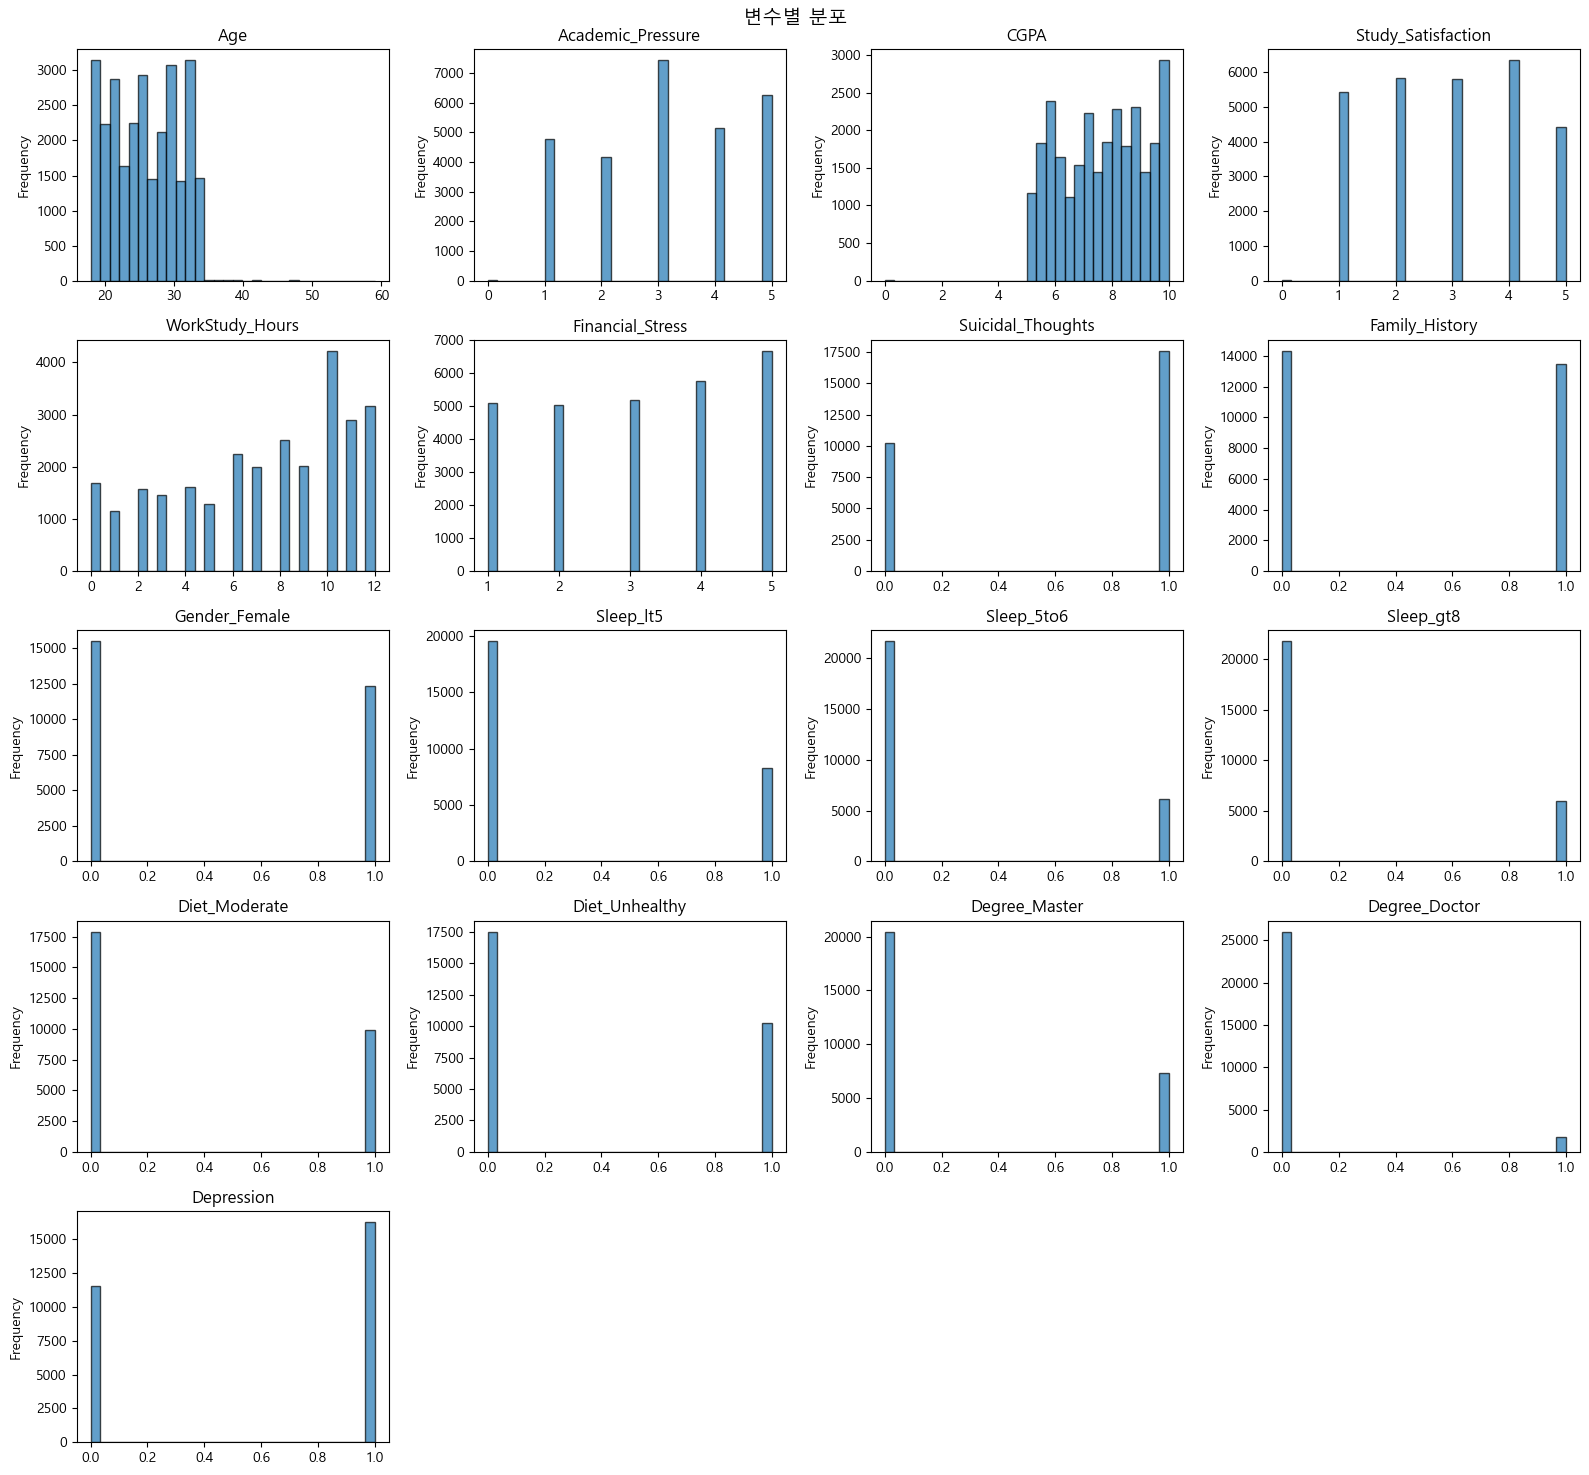

In [5]:
fig, axes = plt.subplots(5, 4, figsize=(16, 15))
axes = axes.flatten()
plot_cols = features + [target]
for i, col in enumerate(plot_cols):
    axes[i].hist(data_model[col], bins=30, edgecolor="black", alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_ylabel("Frequency")
for j in range(len(plot_cols), len(axes)):
    axes[j].axis("off")
plt.suptitle("변수별 분포", fontsize=14)
plt.tight_layout()
plt.show()

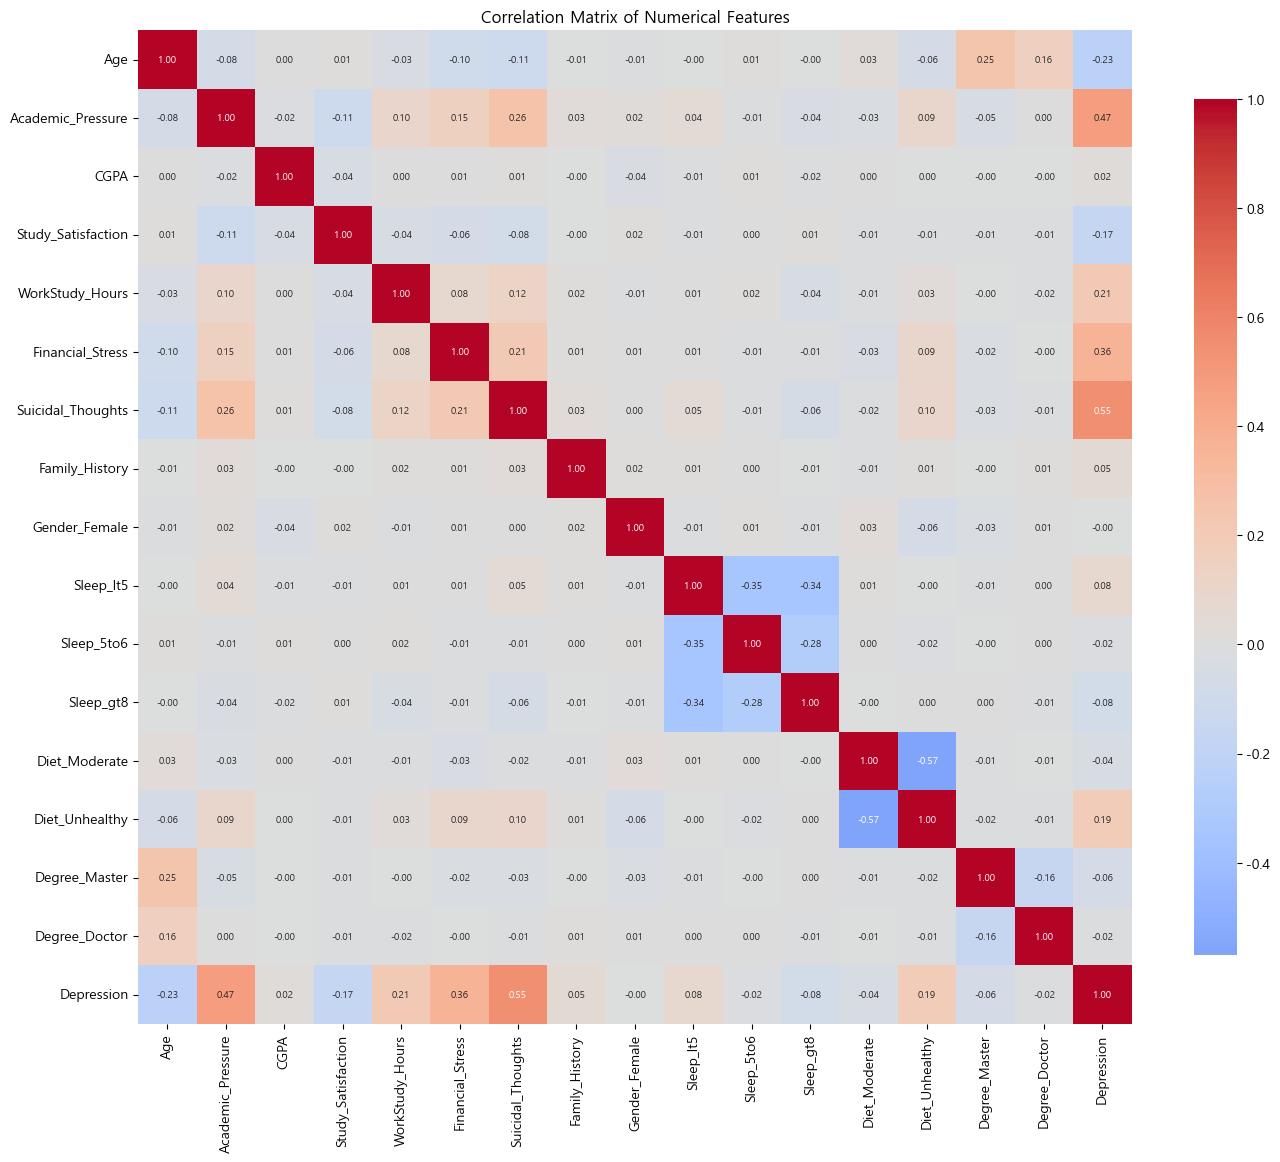


Depression과의 상관계수 (절댓값 상위):
Suicidal_Thoughts     0.546964
Academic_Pressure     0.474898
Financial_Stress      0.363682
Age                   0.227224
WorkStudy_Hours       0.209241
Diet_Unhealthy        0.190032
Study_Satisfaction    0.167855
Sleep_gt8             0.081549
Sleep_lt5             0.079302
Degree_Master         0.063746
Name: Depression, dtype: float64


In [6]:
plt.figure(figsize=(14, 12))
corr = data_model.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.8}, annot_kws={'size': 7})
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

print('\nDepression과의 상관계수 (절댓값 상위):')
print(corr['Depression'].drop('Depression').abs().sort_values(ascending=False).head(10))

자살 생각·학업 압박·재정 스트레스가 최강 상관. L2로 공선성 제어.

### IQR 이상치 제거

In [7]:
before = len(data_model)
mask = pd.Series([True] * before, index=data_model.index)
for col in continuous_cols:
    Q1 = data_model[col].quantile(0.25)
    Q3 = data_model[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    col_mask = data_model[col].between(lower, upper)
    print(f'{col:22s}: 이상치 {(~col_mask).sum():>4d}개 (범위 {lower:.2f} ~ {upper:.2f})')
    mask &= col_mask

data_model = data_model[mask].reset_index(drop=True)
print(f'\n총 {before - len(data_model)}개 이상치 제거 (남은 샘플: {len(data_model)})')

Age                   : 이상치   12개 (범위 7.50 ~ 43.50)
Academic_Pressure     : 이상치    0개 (범위 -1.00 ~ 7.00)
CGPA                  : 이상치    9개 (범위 2.35 ~ 12.87)
Study_Satisfaction    : 이상치    0개 (범위 -1.00 ~ 7.00)
WorkStudy_Hours       : 이상치    0개 (범위 -5.00 ~ 19.00)
Financial_Stress      : 이상치    0개 (범위 -1.00 ~ 7.00)

총 21개 이상치 제거 (남은 샘플: 27781)


## III. 모델링

### 1. 로지스틱 회귀
#### 1.1 적합 — Stratified 70/30, StandardScaler, class_weight='balanced', random_state=42

In [8]:
X = data_model[features].values.astype(float)
y = data_model[target].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

cont_idx = [features.index(c) for c in continuous_cols]
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[:, cont_idx] = scaler.fit_transform(X_train[:, cont_idx])
X_test_scaled[:, cont_idx] = scaler.transform(X_test[:, cont_idx])

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train class balance: {np.bincount(y_train)}')
print(f'Test class balance:  {np.bincount(y_test)}')

Train: (19446, 16), Test: (8335, 16)
Train class balance: [ 8062 11384]
Test class balance:  [3456 4879]


#### C 최적화 — L2, GridSearchCV(scoring=Recall)

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


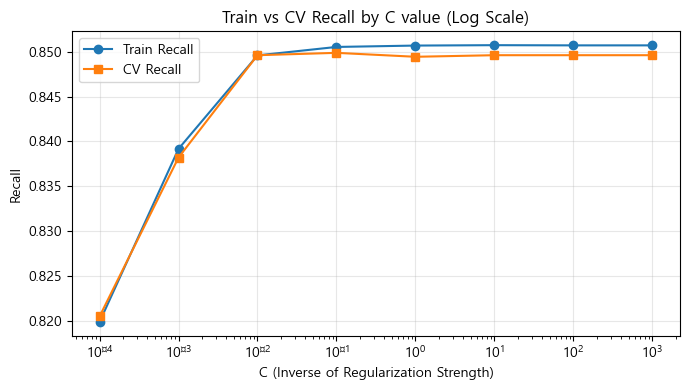

In [9]:
C_grid = np.logspace(-4, 3, 8)
lr_base = LogisticRegression(penalty='l2', solver='lbfgs',
                              class_weight='balanced',
                              max_iter=1000, random_state=RANDOM_STATE)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(lr_base, {'C': C_grid}, scoring='recall', cv=cv, n_jobs=-1,
                    return_train_score=True)
grid.fit(X_train_scaled, y_train)

best_C = grid.best_params_['C']
print(f'최적 C: {best_C}')
print(f'CV Recall: {grid.best_score_:.4f}')

results = grid.cv_results_
plt.figure(figsize=(7, 4))
plt.plot(C_grid, results['mean_train_score'], 'o-', label='Train Recall')
plt.plot(C_grid, results['mean_test_score'], 's-', label='CV Recall')
plt.xscale('log')
plt.xlabel('C (Inverse of Regularization Strength)')
plt.ylabel('Recall')
plt.title('Train vs CV Recall by C value (Log Scale)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 5-Fold 일반화 성능

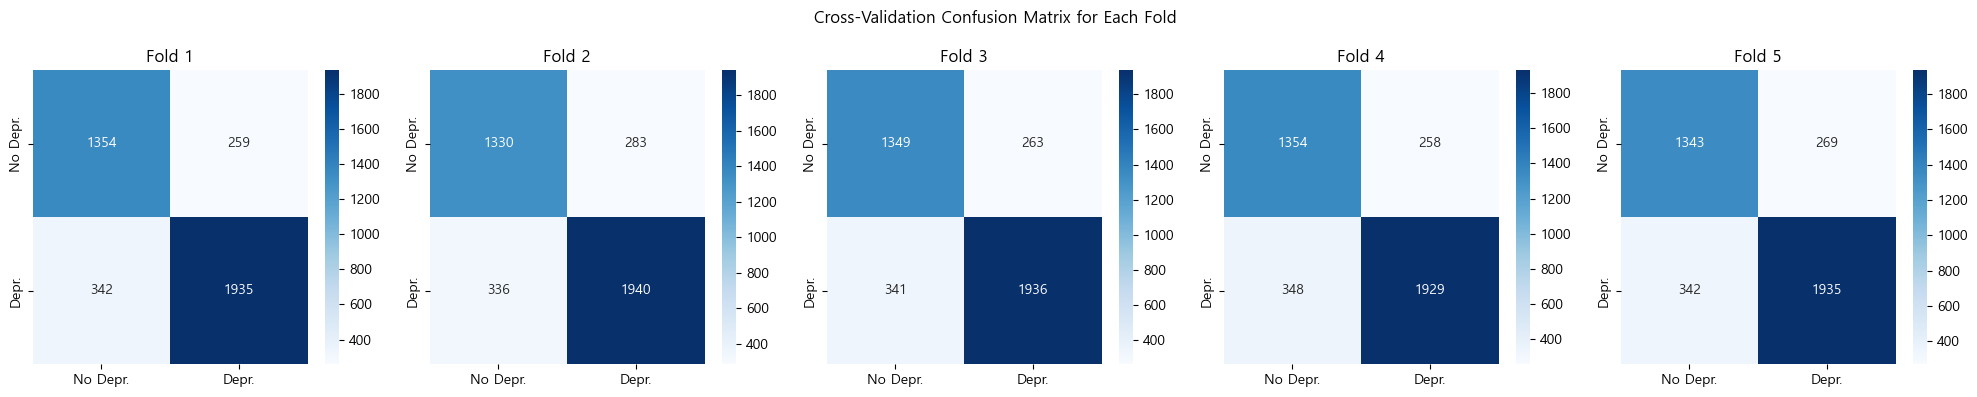

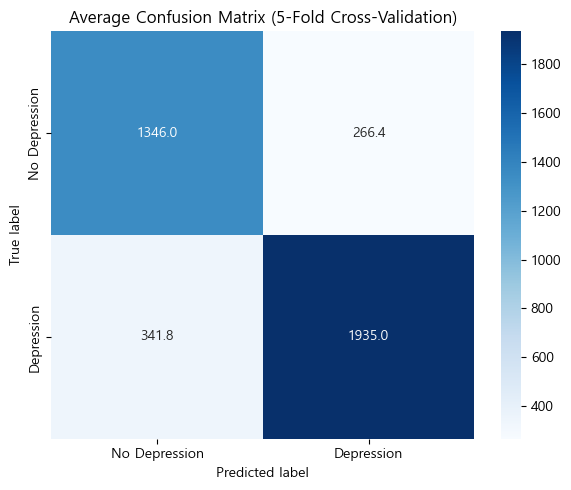


=== 5-Fold CV 결과 ===
   Recall_1  Precision_1    F1_1    F1_0
0    0.8498       0.8820  0.8656  0.8184
1    0.8524       0.8727  0.8624  0.8112
2    0.8502       0.8804  0.8651  0.8171
3    0.8472       0.8820  0.8642  0.8171
4    0.8498       0.8779  0.8636  0.8147

--- 평균 ---
Recall_1       0.8499
Precision_1    0.8790
F1_1           0.8642
F1_0           0.8157
dtype: float64


In [10]:
lr_best = LogisticRegression(penalty='l2', C=best_C, solver='lbfgs',
                              class_weight='balanced',
                              max_iter=1000, random_state=RANDOM_STATE)

fold_cms = []
fold_metrics = []
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (tr_idx, va_idx) in enumerate(cv.split(X_train_scaled, y_train)):
    lr_best.fit(X_train_scaled[tr_idx], y_train[tr_idx])
    y_pred = lr_best.predict(X_train_scaled[va_idx])
    cm = confusion_matrix(y_train[va_idx], y_pred)
    fold_cms.append(cm)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Depr.', 'Depr.'],
                yticklabels=['No Depr.', 'Depr.'])
    axes[i].set_title(f'Fold {i+1}')
    fold_metrics.append({
        'Recall_1':    recall_score(y_train[va_idx], y_pred),
        'Precision_1': precision_score(y_train[va_idx], y_pred),
        'F1_1':        f1_score(y_train[va_idx], y_pred),
        'F1_0':        f1_score(y_train[va_idx], y_pred, pos_label=0)
    })
plt.suptitle('Cross-Validation Confusion Matrix for Each Fold')
plt.tight_layout()
plt.show()

avg_cm = np.mean(fold_cms, axis=0)
plt.figure(figsize=(6, 5))
sns.heatmap(avg_cm, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['No Depression', 'Depression'],
            yticklabels=['No Depression', 'Depression'])
plt.title('Average Confusion Matrix (5-Fold Cross-Validation)')
plt.ylabel('True label'); plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

metrics_df = pd.DataFrame(fold_metrics)
print('\n=== 5-Fold CV 결과 ===')
print(metrics_df.round(4))
print('\n--- 평균 ---')
print(metrics_df.mean().round(4))

#### Threshold 최적화 (F1.3)

Fold별 최적 threshold: [np.float64(0.29), np.float64(0.27), np.float64(0.28), np.float64(0.23), np.float64(0.3)]
평균 최적 threshold: 0.2740

=== Table2. Threshold 별 평가지표 (Test set) ===
   Threshold  Recall  Precision   F1.3
    0.5 (기본)  0.8496     0.8823 0.8614
    0.3 (예시)  0.9309     0.8213 0.8869
0.2740 (최적화)  0.9385     0.8133 0.8877


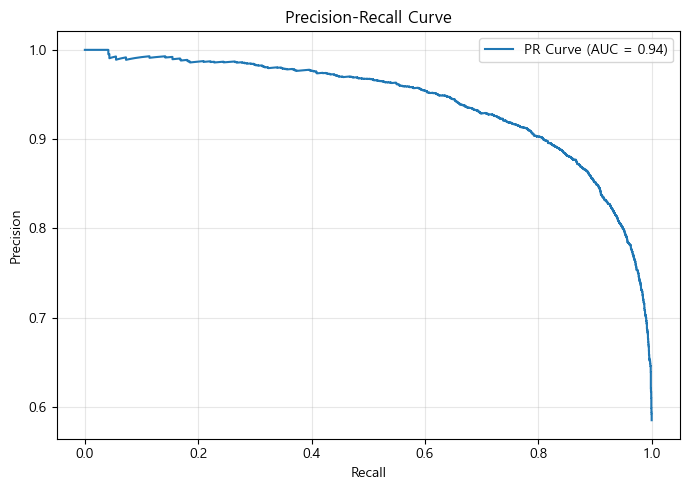

In [11]:
best_thresholds = []
for tr_idx, va_idx in cv.split(X_train_scaled, y_train):
    lr_best.fit(X_train_scaled[tr_idx], y_train[tr_idx])
    y_prob = lr_best.predict_proba(X_train_scaled[va_idx])[:, 1]
    thresholds = np.linspace(0.05, 0.95, 91)
    scores = [fbeta_score(y_train[va_idx], (y_prob >= t).astype(int), beta=1.3)
              for t in thresholds]
    best_thresholds.append(thresholds[np.argmax(scores)])

best_threshold = float(np.mean(best_thresholds))
print(f'Fold별 최적 threshold: {[round(t, 4) for t in best_thresholds]}')
print(f'평균 최적 threshold: {best_threshold:.4f}')

lr_best.fit(X_train_scaled, y_train)
y_prob_test = lr_best.predict_proba(X_test_scaled)[:, 1]

results_thr = []
for thr, label in [(0.5, '0.5 (기본)'),
                   (0.3, '0.3 (예시)'),
                   (best_threshold, f'{best_threshold:.4f} (최적화)')]:
    y_pred_thr = (y_prob_test >= thr).astype(int)
    results_thr.append({
        'Threshold': label,
        'Recall':    recall_score(y_test, y_pred_thr),
        'Precision': precision_score(y_test, y_pred_thr),
        'F1.3':      fbeta_score(y_test, y_pred_thr, beta=1.3)
    })
thr_df = pd.DataFrame(results_thr)
print('\n=== Table2. Threshold 별 평가지표 (Test set) ===')
print(thr_df.round(4).to_string(index=False))

precisions, recalls, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc = auc(recalls, precisions)
plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, label=f'PR Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 1.2 회귀계수 / 오즈비

=== Table3. 최종 로지스틱 모형 ===
          Variable  Coefficient  Odds_Ratio
 Suicidal_Thoughts       2.4633     11.7430
 Academic_Pressure       1.1150      3.0495
    Diet_Unhealthy       1.0118      2.7506
  Financial_Stress       0.7863      2.1953
     Diet_Moderate       0.4578      1.5805
   WorkStudy_Hours       0.4181      1.5191
         Sleep_lt5       0.3427      1.4087
    Family_History       0.2345      1.2643
     Degree_Doctor       0.0979      1.1028
              CGPA       0.0738      1.0766
        Sleep_5to6       0.0230      1.0233
     Gender_Female       0.0094      1.0095
     Degree_Master       0.0013      1.0013
         Sleep_gt8      -0.2602      0.7709
Study_Satisfaction      -0.3324      0.7172
               Age      -0.5357      0.5852


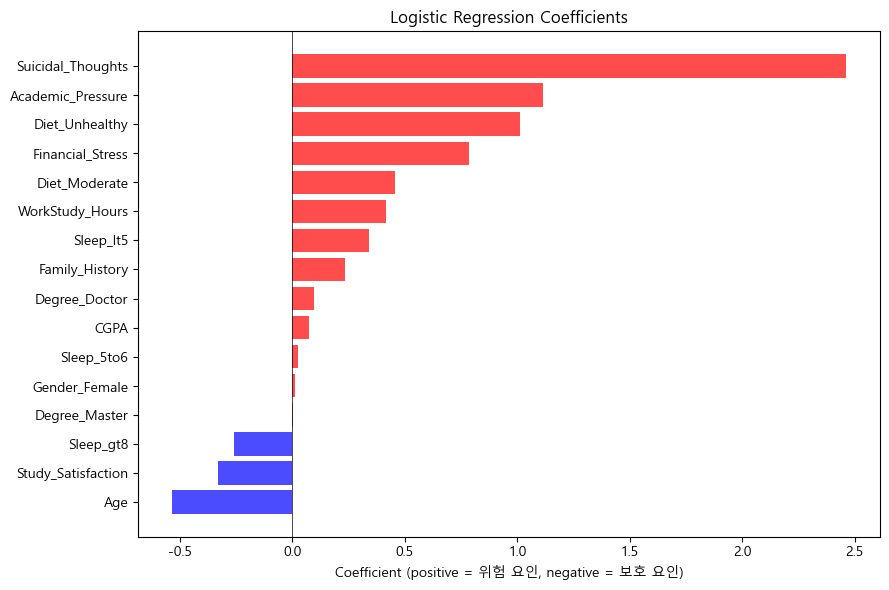

In [12]:
coef = lr_best.coef_[0]
coef_df = pd.DataFrame({
    'Variable':    features,
    'Coefficient': coef,
    'Odds_Ratio':  np.exp(coef)
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)

print('=== Table3. 최종 로지스틱 모형 ===')
print(coef_df.round(4).to_string(index=False))

plt.figure(figsize=(9, 6))
colors = ['red' if c > 0 else 'blue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Variable'], coef_df['Coefficient'], color=colors, alpha=0.7)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel('Coefficient (positive = 위험 요인, negative = 보호 요인)')
plt.title('Logistic Regression Coefficients')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### 1.3 Box-Tidwell 선형성 검정

=== Box-Tidwell Test ===
          Variable  p-value (interaction)  Linearity OK (p > 0.05)
               Age                 0.0000                    False
 Academic_Pressure                 0.0000                    False
              CGPA                 0.9838                     True
Study_Satisfaction                 0.3112                     True
   WorkStudy_Hours                 0.0596                     True
  Financial_Stress                 0.0748                     True


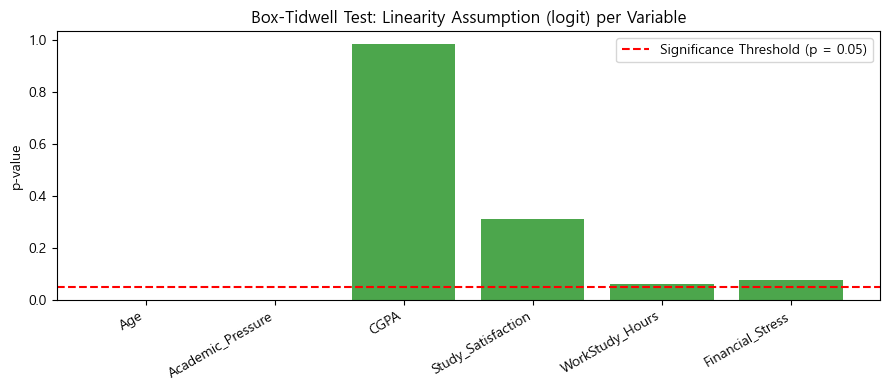

In [13]:
import statsmodels.api as sm

X_bt = data_model[features].copy().astype(float)
y_bt = data_model[target].astype(int)
shift = 0.001

pvalues = {}
for col in continuous_cols:
    X_aug = X_bt.copy()
    x_shift = X_aug[col] + shift
    X_aug[f'{col}_logint'] = x_shift * np.log(x_shift)
    X_aug = sm.add_constant(X_aug)
    try:
        model = sm.Logit(y_bt, X_aug).fit(disp=False, maxiter=200)
        pvalues[col] = model.pvalues[f'{col}_logint']
    except Exception as e:
        pvalues[col] = np.nan
        print(f'{col} 검정 실패: {e}')

bt_df = pd.DataFrame({'Variable': list(pvalues.keys()),
                      'p-value (interaction)': list(pvalues.values())})
bt_df['Linearity OK (p > 0.05)'] = bt_df['p-value (interaction)'] > 0.05
print('=== Box-Tidwell Test ===')
print(bt_df.round(4).to_string(index=False))

plt.figure(figsize=(9, 4))
colors = ['green' if v else 'orange' for v in bt_df['Linearity OK (p > 0.05)']]
plt.bar(bt_df['Variable'], bt_df['p-value (interaction)'], color=colors, alpha=0.7)
plt.axhline(0.05, color='red', linestyle='--', label='Significance Threshold (p = 0.05)')
plt.title('Box-Tidwell Test: Linearity Assumption (logit) per Variable')
plt.xticks(rotation=30, ha='right')
plt.ylabel('p-value')
plt.legend()
plt.tight_layout()
plt.show()

LR의 선형성 한계 보완 → RF 도입.

### 2. 랜덤포레스트
#### 2.1 GridSearchCV (Recall 기준)

In [14]:
rf_default = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
rf_default.fit(X_train, y_train)
y_pred_def = rf_default.predict(X_test)

print('=== 하이퍼파라미터 튜닝 전 (Default Random Forest) ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred_def):.4f}')
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_def))
print('Classification Report:')
print(classification_report(y_test, y_pred_def))

=== 하이퍼파라미터 튜닝 전 (Default Random Forest) ===
Accuracy: 0.8412
Confusion Matrix:
[[2709  747]
 [ 577 4302]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.78      0.80      3456
           1       0.85      0.88      0.87      4879

    accuracy                           0.84      8335
   macro avg       0.84      0.83      0.84      8335
weighted avg       0.84      0.84      0.84      8335



In [15]:
param_grid_rf = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
                       param_grid_rf, cv=cv, scoring='recall', n_jobs=-1, verbose=0)
grid_rf.fit(X_train, y_train)

print(f'최적 파라미터: {grid_rf.best_params_}')
print(f'CV Best Recall: {grid_rf.best_score_:.4f}')

rf_best = grid_rf.best_estimator_
y_pred_rf = rf_best.predict(X_test)

print('\n=== 하이퍼파라미터 튜닝 후 ===')
print(f'Test Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_rf))
print('Classification Report:')
print(classification_report(y_test, y_pred_rf))

최적 파라미터: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
CV Best Recall: 0.8858

=== 하이퍼파라미터 튜닝 후 ===
Test Accuracy: 0.8420
Confusion Matrix:
[[2695  761]
 [ 556 4323]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.78      0.80      3456
           1       0.85      0.89      0.87      4879

    accuracy                           0.84      8335
   macro avg       0.84      0.83      0.84      8335
weighted avg       0.84      0.84      0.84      8335



In [ ]:
from sklearn.metrics import classification_report

cm = confusion_matrix(y_test, y_pred_rf)
report_dict = classification_report(y_test, y_pred_rf, output_dict=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = ['No Depression', 'Depression']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Count'}, annot_kws={'size': 14})
axes[0].set_title(f'Confusion Matrix (Tuned RF, Test Acc={accuracy_score(y_test, y_pred_rf):.4f})',
                  fontsize=12)
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('True label')

tn, fp, fn, tp = cm.ravel()
for (i, j), txt in [((0,0), f'TN'), ((0,1), f'FP'), ((1,0), f'FN'), ((1,1), f'TP')]:
    axes[0].text(j + 0.5, i + 0.75, txt, ha='center', va='center',
                 fontsize=10, color='red', fontweight='bold')

report_df = pd.DataFrame(report_dict).T.iloc[:2][['precision', 'recall', 'f1-score']]
report_df.index = ['Class 0 (No Depr.)', 'Class 1 (Depr.)']
sns.heatmap(report_df, annot=True, fmt='.3f', cmap='YlGnBu', ax=axes[1],
            vmin=0.7, vmax=1.0, cbar_kws={'label': 'Score'}, annot_kws={'size': 12})
axes[1].set_title('Classification Report (Tuned RF)', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print()
print('=== Tuned RF Summary ===')
print(f'Test Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'TN={tn}, FP={fp}, FN={fn}, TP={tp}')
print(f'Class 1 Recall    (FN 최소화 목표) : {tp/(tp+fn):.4f}')
print(f'Class 1 Precision (오진 통제)      : {tp/(tp+fp):.4f}')
print(f'Class 1 F1                       : {report_dict["1"]["f1-score"]:.4f}')

#### 2.2 Feature Importance (Gini)

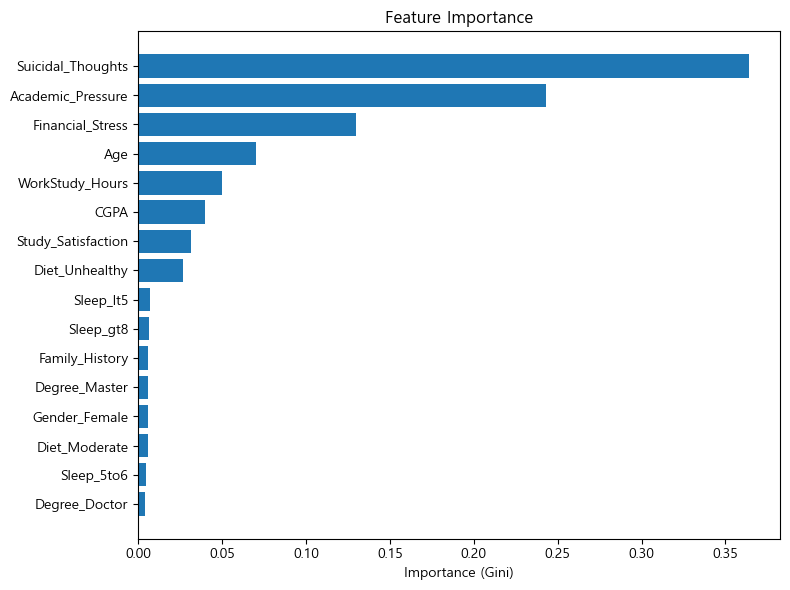

           Feature  Importance
 Suicidal_Thoughts      0.3643
 Academic_Pressure      0.2428
  Financial_Stress      0.1298
               Age      0.0701
   WorkStudy_Hours      0.0497
              CGPA      0.0395
Study_Satisfaction      0.0314
    Diet_Unhealthy      0.0265
         Sleep_lt5      0.0071
         Sleep_gt8      0.0066
    Family_History      0.0061
     Degree_Master      0.0059
     Gender_Female      0.0056
     Diet_Moderate      0.0056
        Sleep_5to6      0.0047
     Degree_Doctor      0.0042


In [16]:
fi = pd.DataFrame({
    'Feature':    features,
    'Importance': rf_best.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(fi['Feature'], fi['Importance'])
plt.title('Feature Importance')
plt.xlabel('Importance (Gini)')
plt.tight_layout()
plt.show()

print(fi.sort_values('Importance', ascending=False).round(4).to_string(index=False))

#### 2.3 Permutation Importance

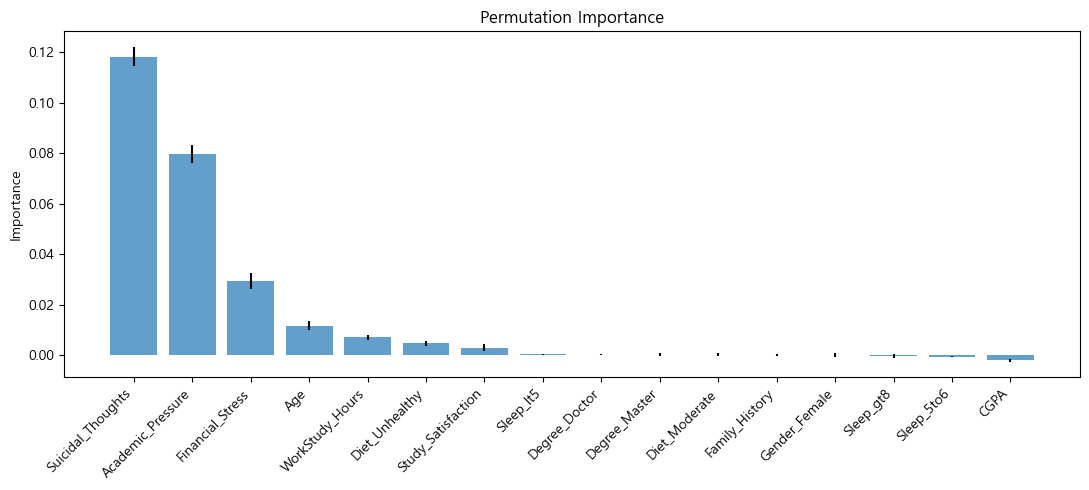

           Feature  Importance    Std
 Suicidal_Thoughts      0.1183 0.0038
 Academic_Pressure      0.0797 0.0036
  Financial_Stress      0.0295 0.0031
               Age      0.0118 0.0018
   WorkStudy_Hours      0.0072 0.0010
    Diet_Unhealthy      0.0048 0.0011
Study_Satisfaction      0.0031 0.0013
         Sleep_lt5      0.0004 0.0004
     Degree_Doctor      0.0003 0.0002
     Degree_Master      0.0003 0.0006
     Diet_Moderate      0.0003 0.0005
    Family_History      0.0003 0.0004
     Gender_Female      0.0001 0.0007
         Sleep_gt8     -0.0003 0.0007
        Sleep_5to6     -0.0005 0.0003
              CGPA     -0.0018 0.0006


In [17]:
perm = permutation_importance(rf_best, X_test, y_test, n_repeats=10,
                              random_state=RANDOM_STATE, scoring='accuracy', n_jobs=-1)
perm_df = pd.DataFrame({
    'Feature':    features,
    'Importance': perm.importances_mean,
    'Std':        perm.importances_std
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(11, 5))
plt.bar(perm_df['Feature'], perm_df['Importance'], yerr=perm_df['Std'], alpha=0.7)
plt.title('Permutation Importance')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print(perm_df.round(4).to_string(index=False))

#### 2.4 SHAP — 종합 해석

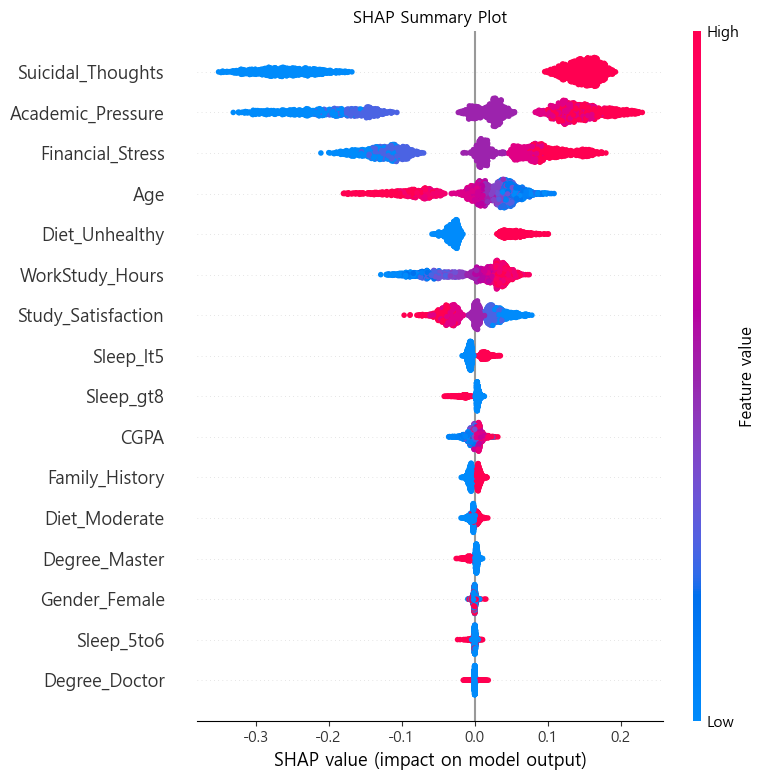

In [ ]:
import shap

n_sample = min(2000, len(X_test))
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X_test), size=n_sample, replace=False)
X_test_sample = X_test[sample_idx]
X_test_df = pd.DataFrame(X_test_sample, columns=features)

explainer = shap.TreeExplainer(rf_best)
shap_values = explainer.shap_values(X_test_sample)

if isinstance(shap_values, list):
    sv = shap_values[1]
elif shap_values.ndim == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

shap.summary_plot(sv, X_test_df, show=False)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.show()

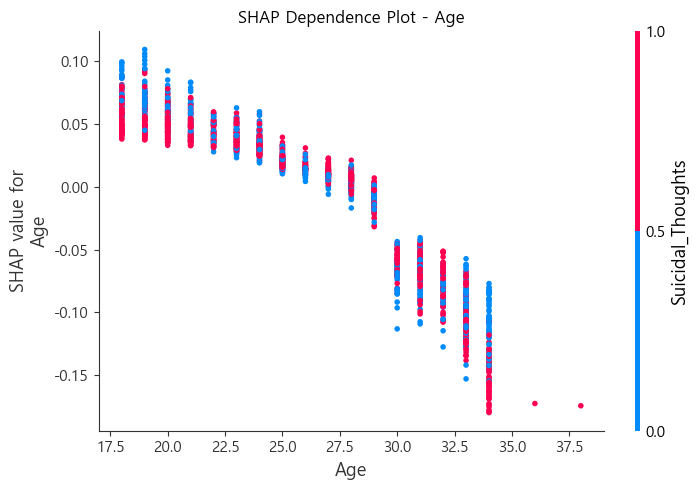

In [19]:
shap.dependence_plot('Age', sv, X_test_df,
                     interaction_index='Suicidal_Thoughts', show=False)
plt.title('SHAP Dependence Plot - Age')
plt.tight_layout()
plt.show()

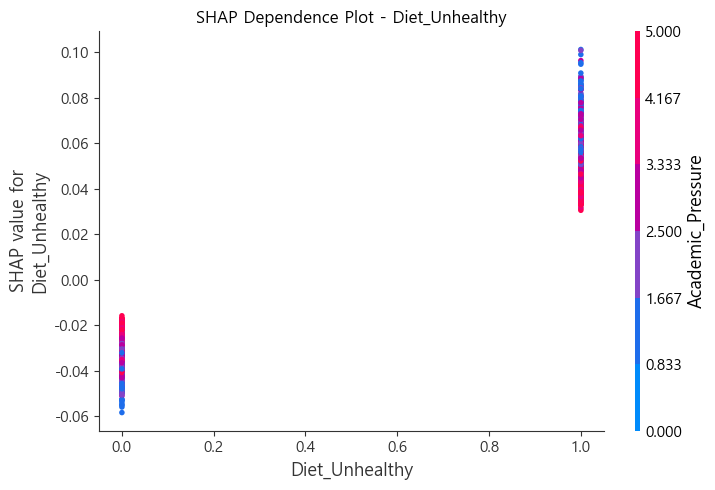

In [20]:
shap.dependence_plot('Diet_Unhealthy', sv, X_test_df,
                     interaction_index='Academic_Pressure', show=False)
plt.title('SHAP Dependence Plot - Diet_Unhealthy')
plt.tight_layout()
plt.show()

#### 2.5 저평가 변수 재발견 (Sleep, Family History)

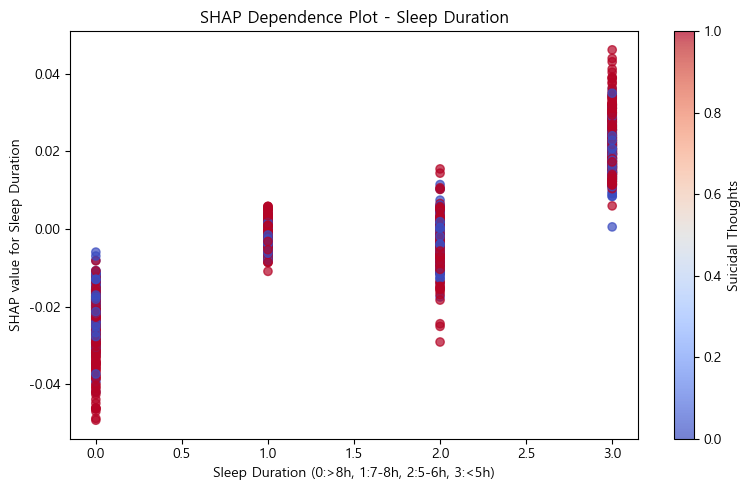

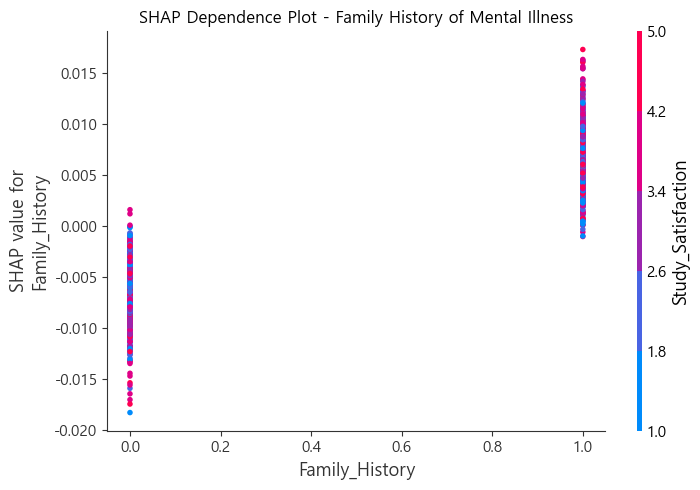

In [21]:
# Sleep level mapping — 0: >8h, 1: 7-8h (baseline), 2: 5-6h, 3: <5h
sleep_level = (X_test_df['Sleep_gt8'] * 0
               + (1 - X_test_df['Sleep_lt5'] - X_test_df['Sleep_5to6'] - X_test_df['Sleep_gt8']) * 1
               + X_test_df['Sleep_5to6'] * 2
               + X_test_df['Sleep_lt5'] * 3)
sleep_shap = (sv[:, features.index('Sleep_lt5')]
              + sv[:, features.index('Sleep_5to6')]
              + sv[:, features.index('Sleep_gt8')])

plt.figure(figsize=(8, 5))
scatter = plt.scatter(sleep_level, sleep_shap,
                      c=X_test_df['Suicidal_Thoughts'], cmap='coolwarm', alpha=0.7)
plt.colorbar(scatter, label='Suicidal Thoughts')
plt.xlabel('Sleep Duration (0:>8h, 1:7-8h, 2:5-6h, 3:<5h)')
plt.ylabel('SHAP value for Sleep Duration')
plt.title('SHAP Dependence Plot - Sleep Duration')
plt.tight_layout()
plt.show()

shap.dependence_plot('Family_History', sv, X_test_df,
                     interaction_index='Study_Satisfaction', show=False)
plt.title('SHAP Dependence Plot - Family History of Mental Illness')
plt.tight_layout()
plt.show()

## IV. 결론

### 성능

| 모델 | Recall | Precision |
|---|---|---|
| LR (thr=0.5) | 0.850 | 0.882 |
| **LR (thr=0.274)** | **0.939** | 0.813 |
| RF (default) | 0.88 | 0.85 |
| RF (tuned) | 0.89 | 0.85 |

FN: 577 → 556 (−21건)

### 위험 · 보호 요인 (OR)

- 위험: Suicidal (11.74), Academic (3.05), Diet (2.75), Financial (2.20)
- 보호: Age (0.59), Study_Sat (0.72), Sleep_gt8 (0.77)

### 다층 해석 요약

| 발견 | 단일 지표 | SHAP |
|---|---|---|
| Age | OR=0.59 선형 | 27~28세 분기 비선형 |
| Sleep | Perm≈0 | 단조 패턴 회복 |
| CGPA | OR=1.08 | Perm=−0.002 (노이즈) |

### 한계
인도 단일 문화권 · 횡단면 · 자가보고. 임상 1차 스크리닝 보조용.

> 상세는 [보고서](./ML보고서.pdf) 참조.